In [ ]:
import os
os.chdir('/workspaces/korea-real-estate-population-movement')

from src.config import DB_URL
import pandas as pd
from sqlalchemy import create_engine, inspect
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.font_manager as fm
fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)
[f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
plt.rcParams["font.family"] = "NanumGothic"

In [ ]:
engine = create_engine(DB_URL)

def read_sql_file(path):
    with open(path,"r") as f:
        return f.read()


In [ ]:
inspector = inspect(engine)

for table in inspector.get_table_names():
    print(f"\n--- {table} ---")
    
    for column in inspector.get_columns(table):
        print(column["name"], column["type"])

In [ ]:
df = pd.read_sql(
    f"SELECT * FROM seoul_population_flow LIMIT 5",
    engine
)

display(df)


# Districts with the highest number of inflow and outflow

In [18]:
cumulative_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_outflow.sql')
yearly_top_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_outflow.sql')

top_outflow_districts = pd.read_sql_query(cumulative_outflow_query,engine)
yearly_outflow = pd.read_sql_query(yearly_top_outflow_query,engine)

display(top_outflow_districts)
display(yearly_outflow)

,from_district,total_outflow
0,강남구,111479
1,송파구,91461
2,강동구,87685
3,서초구,81438
4,관악구,74563


,from_district,year,total_outflow
0,강남구,2023,40941
1,송파구,2023,29824
2,서초구,2023,27351
3,관악구,2023,23259
4,강동구,2023,18988
5,강남구,2024,38734
6,강동구,2024,32250
7,송파구,2024,31433
8,서초구,2024,25268
9,관악구,2024,24842


In [20]:
cumulative_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_inflow.sql')
yearly_top_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_inflow.sql')

top_inflow_districts = pd.read_sql_query(cumulative_inflow_query,engine)
yearly_inflow = pd.read_sql_query(yearly_top_inflow_query,engine)

display(top_inflow_districts)
display(yearly_inflow)

,to_district,total_inflow
0,송파구,97488
1,강남구,95996
2,관악구,90329
3,동작구,76480
4,영등포구,75434


,to_district,year,total_inflow
0,강남구,2023,30791
1,관악구,2023,30381
2,송파구,2023,30054
3,동작구,2023,25378
4,영등포구,2023,24706
5,송파구,2024,32235
6,강남구,2024,31058
7,관악구,2024,30442
8,동작구,2024,25229
9,영등포구,2024,24932


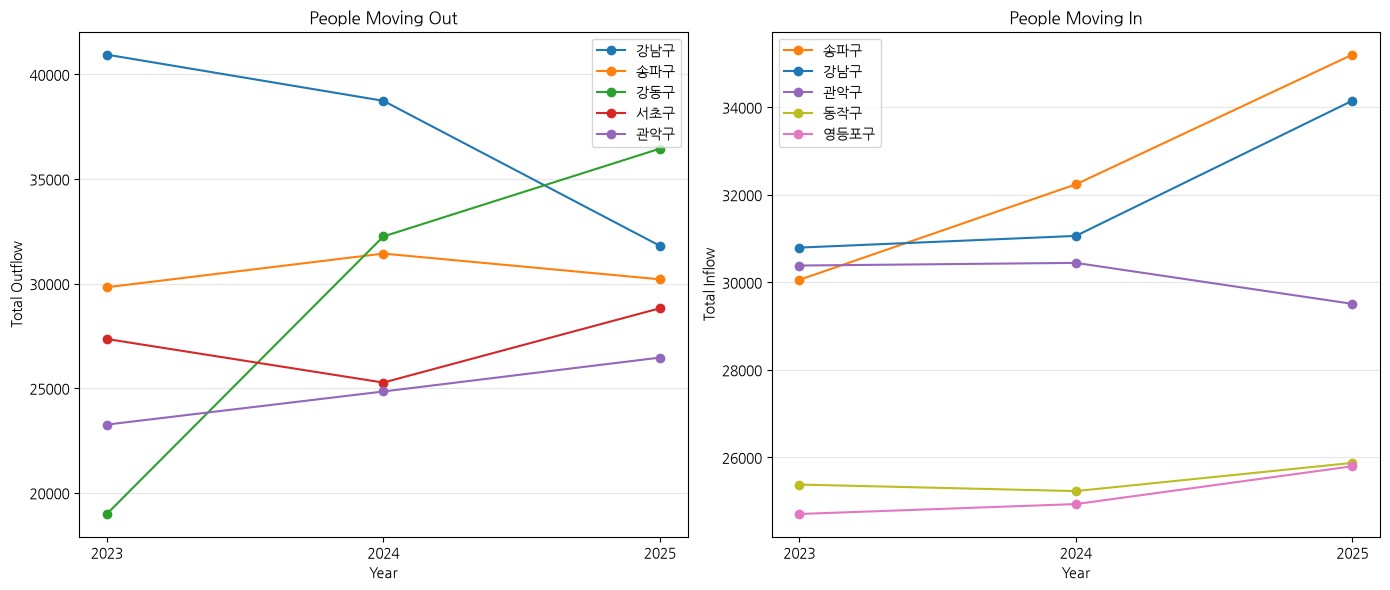

In [28]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,6))

district_colors = {
    "강남구": "tab:blue",
    "송파구": "tab:orange",
    "강동구": "tab:green",
    "서초구": "tab:red",
    "관악구": "tab:purple",
    "동작구": "tab:olive",
    "영등포구": "tab:pink"
}

for district in top_outflow_districts['from_district']:
    district_df = yearly_outflow[yearly_outflow['from_district'] == district]
    ax1.plot(
        district_df['year'],
        district_df['total_outflow'],
        marker="o",
        label=district,
        color=district_colors[district]
    )

ax1.set_xticks([2023, 2024, 2025])
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Outflow")
ax1.set_title("People Moving Out")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

for district in top_inflow_districts['to_district']:
    district_df = yearly_inflow[yearly_inflow['to_district'] == district]

    ax2.plot(
        district_df['year'],
        district_df['total_inflow'],
        marker='o',
        label=district,
        color=district_colors[district]
    )

ax2.set_xticks([2023, 2024, 2025])
ax2.set_xlabel("Year")
ax2.set_ylabel("Total Inflow")
ax2.set_title("People Moving In")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()